# 04 - Texte : Modélisation Baseline

## Objectif de ce notebook
Établir une **référence de performance** en entraînant plusieurs modèles baselines sur les données texte nettoyées (prédiction du `prdtypecode` en 27 classes).

**Prérequis** : Exécuter les notebooks 01, 02 et 03 pour disposer des données dans `data/processed/`.

**Livrable** : Modèle baseline de référence (ex. SVM Linear ~78% F1-macro), vectoriseur TF-IDF et label encoder sauvegardés dans `models/`.

---

## Plan
1. Chargement des données nettoyées
2. Vectorisation des textes (TF-IDF)
3. Préparation des labels et division train/validation
4. Entraînement des modèles baselines (NB, LogReg, SVM, RF)
5. Évaluation et comparaison des modèles
6. Visualisations, matrice de confusion, analyse du meilleur modèle
7. Validation croisée et analyse des erreurs
8. Sauvegarde des modèles et recommandations pour le notebook 05



In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Ajouter le dossier src au path
sys.path.append(str(Path('../').resolve()))

# Import des modules de modélisation
from src.utils.data_loader import load_data
from src.modeling import TFIDFVectorizer, BaselineModels
from src.evaluation import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    plot_class_distribution
)

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")



✅ Bibliothèques importées avec succès


## 1. Chargement des Données Nettoyées

Chargement des datasets préprocessés depuis `data/processed/`.


In [2]:
# Chargement des données nettoyées
DATA_DIR = Path('../data/processed')

print("🔄 Chargement des données nettoyées...")

X_train = pd.read_csv(DATA_DIR / 'X_train_clean.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_clean.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv')

print(f"✅ Données chargées avec succès !")
print(f"\n📊 Dimensions des datasets :")
print(f"  - X_train : {X_train.shape[0]:,} lignes × {X_train.shape[1]} colonnes")
print(f"  - X_test  : {X_test.shape[0]:,} lignes × {X_test.shape[1]} colonnes")
print(f"  - y_train : {y_train.shape[0]:,} lignes × {y_train.shape[1]} colonnes")

# Vérification
print(f"\n✅ Vérifications :")
print(f"  - Alignement X_train/y_train : {X_train.shape[0] == y_train.shape[0]}")
print(f"  - Colonne text_combined présente : {'text_combined' in X_train.columns}")
print(f"  - Nombre de classes : {y_train['prdtypecode'].nunique()}")

# Aperçu
print(f"\n📝 Aperçu des données :")
print(f"  - Exemple de texte combiné (premiers 200 caractères) :")
print(f"    {X_train['text_combined'].iloc[0][:200]}...")



🔄 Chargement des données nettoyées...
✅ Données chargées avec succès !

📊 Dimensions des datasets :
  - X_train : 84,916 lignes × 17 colonnes
  - X_test  : 13,812 lignes × 17 colonnes
  - y_train : 84,916 lignes × 2 colonnes

✅ Vérifications :
  - Alignement X_train/y_train : True
  - Colonne text_combined présente : True
  - Nombre de classes : 27

📝 Aperçu des données :
  - Exemple de texte combiné (premiers 200 caractères) :
    olivia: personalisiertes notizbuch / 150 seiten / punktraster / ca din a5 / rosen-design...


## 2. Vectorisation des Textes (TF-IDF)

Transformation des textes en vecteurs numériques pour la modélisation.


In [3]:
# Préparation des textes
X_train_texts = X_train['text_combined'].astype(str)
X_test_texts = X_test['text_combined'].astype(str)

print("🔄 Vectorisation TF-IDF...")
print(f"  - Nombre de textes d'entraînement : {len(X_train_texts):,}")
print(f"  - Nombre de textes de test : {len(X_test_texts):,}")

# Création et entraînement du vectoriseur
vectorizer = TFIDFVectorizer(
    max_features=10000,      # Limiter le vocabulaire à 10 000 mots
    min_df=2,                 # Mots apparaissant au moins 2 fois
    max_df=0.95,              # Mots apparaissant dans max 95% des documents
    ngram_range=(1, 2),       # Unigrams et bigrams
    lowercase=True,
    stop_words='french'       # Stop words français
)

# Entraînement sur les données d'entraînement uniquement
X_train_vect = vectorizer.fit_transform(X_train_texts)
X_test_vect = vectorizer.transform(X_test_texts)

print(f"✅ Vectorisation terminée !")
print(f"\n📊 Caractéristiques des vecteurs :")
print(f"  - Taille du vocabulaire : {vectorizer.get_vocabulary_size():,} mots")
print(f"  - Dimensions X_train_vect : {X_train_vect.shape}")
print(f"  - Dimensions X_test_vect : {X_test_vect.shape}")
print(f"  - Densité (sparsity) : {(1 - X_train_vect.nnz / (X_train_vect.shape[0] * X_train_vect.shape[1])) * 100:.2f}%")



🔄 Vectorisation TF-IDF...
  - Nombre de textes d'entraînement : 84,916
  - Nombre de textes de test : 13,812
✅ Vectorisation terminée !

📊 Caractéristiques des vecteurs :
  - Taille du vocabulaire : 10,000 mots
  - Dimensions X_train_vect : (84916, 10000)
  - Dimensions X_test_vect : (13812, 10000)
  - Densité (sparsity) : 99.55%


## 3. Préparation des Labels

Encodage des labels pour la modélisation.


In [4]:
# Extraction des labels
y_train_labels = y_train['prdtypecode'].values

# Encodage des labels (déjà numériques, mais on s'assure qu'ils sont bien encodés)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_labels)

# Vérification
print("📊 Préparation des labels :")
print(f"  - Nombre de classes : {len(label_encoder.classes_)}")
print(f"  - Classes : {sorted(label_encoder.classes_)}")
print(f"  - Distribution des classes (top 10) :")
class_counts = pd.Series(y_train_encoded).value_counts().head(10)
for idx, count in class_counts.items():
    original_class = label_encoder.inverse_transform([idx])[0]
    print(f"    Classe {original_class} : {count} occurrences ({count/len(y_train_encoded)*100:.2f}%)")

# Sauvegarde du label encoder pour plus tard
import pickle
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
with open(MODELS_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"\n✅ Label encoder sauvegardé dans {MODELS_DIR / 'label_encoder.pkl'}")



📊 Préparation des labels :
  - Nombre de classes : 27
  - Classes : [np.int64(10), np.int64(40), np.int64(50), np.int64(60), np.int64(1140), np.int64(1160), np.int64(1180), np.int64(1280), np.int64(1281), np.int64(1300), np.int64(1301), np.int64(1302), np.int64(1320), np.int64(1560), np.int64(1920), np.int64(1940), np.int64(2060), np.int64(2220), np.int64(2280), np.int64(2403), np.int64(2462), np.int64(2522), np.int64(2582), np.int64(2583), np.int64(2585), np.int64(2705), np.int64(2905)]
  - Distribution des classes (top 10) :
    Classe 2583 : 10209 occurrences (12.02%)
    Classe 1560 : 5073 occurrences (5.97%)
    Classe 1300 : 5045 occurrences (5.94%)
    Classe 2060 : 4993 occurrences (5.88%)
    Classe 2522 : 4989 occurrences (5.88%)
    Classe 1280 : 4870 occurrences (5.74%)
    Classe 2403 : 4774 occurrences (5.62%)
    Classe 2280 : 4760 occurrences (5.61%)
    Classe 1920 : 4303 occurrences (5.07%)
    Classe 1160 : 3953 occurrences (4.66%)

✅ Label encoder sauvegardé dans ..

## 4. Division Train/Validation

Création d'un ensemble de validation pour évaluer les modèles.


In [5]:
# Division train/validation (80/20)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_vect,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded  # Conserver la distribution des classes
)

print("📊 Division Train/Validation :")
print(f"  - Train : {X_train_split.shape[0]:,} échantillons")
print(f"  - Validation : {X_val_split.shape[0]:,} échantillons")
print(f"  - Ratio : {X_train_split.shape[0] / X_val_split.shape[0]:.2f}")

# Vérification de la distribution des classes
print(f"\n✅ Distribution des classes (validation) :")
val_class_counts = pd.Series(y_val_split).value_counts()
print(f"  - Nombre de classes représentées : {len(val_class_counts)}")
print(f"  - Classe la plus fréquente : {val_class_counts.max()} occurrences")
print(f"  - Classe la moins fréquente : {val_class_counts.min()} occurrences")



📊 Division Train/Validation :
  - Train : 67,932 échantillons
  - Validation : 16,984 échantillons
  - Ratio : 4.00

✅ Distribution des classes (validation) :
  - Nombre de classes représentées : 27
  - Classe la plus fréquente : 2042 occurrences
  - Classe la moins fréquente : 153 occurrences


## 5. Entraînement des Modèles Baselines

Entraînement de plusieurs modèles baselines pour comparer leurs performances.


In [6]:
# Création des modèles baselines
baseline_models = BaselineModels(random_state=42)
models = baseline_models.create_baseline_models()

print("📋 Modèles baselines créés :")
for model_name in models.keys():
    print(f"  - {model_name}")

print(f"\n🔄 Entraînement des modèles...")
print("="*80)

# Entraînement de tous les modèles
import time
start_time = time.time()
trained_models = baseline_models.train_all_models(X_train_split, y_train_split)
elapsed = time.time() - start_time
print(f"Temps d'entraînement : {elapsed} secondes")

print("\n" + "="*80)
print("✅ Tous les modèles ont été entraînés avec succès !")



📋 Modèles baselines créés :
  - Naive Bayes
  - Logistic Regression
  - SVM (Linear)
  - Random Forest

🔄 Entraînement des modèles...
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Random Forest...
✅ Random Forest entraîné avec succès
Temps d'entraînement : 21.607561349868774 secondes

✅ Tous les modèles ont été entraînés avec succès !


## 6. Évaluation des Modèles

Évaluation des modèles sur l'ensemble de validation avec des métriques adaptées au déséquilibre.


In [7]:
# Prédictions sur l'ensemble de validation
print("="*80)
print("ÉVALUATION DES MODÈLES SUR L'ENSEMBLE DE VALIDATION")
print("="*80)

results_summary = []

for model_name in trained_models.keys():
    print(f"\n{'='*80}")
    print(f"Modèle : {model_name}")
    print(f"{'='*80}")
    
    # Prédictions
    y_pred = baseline_models.predict(model_name, X_val_split)
    
    # Évaluation
    metrics = evaluate_model(y_val_split, y_pred)
    
    # Afficher les métriques
    print(f"\n📊 Métriques :")
    print(f"  - Accuracy : {metrics['accuracy']:.4f}")
    print(f"  - Precision (macro) : {metrics['precision_macro']:.4f}")
    print(f"  - Recall (macro) : {metrics['recall_macro']:.4f}")
    print(f"  - F1-score (macro) : {metrics['f1_macro']:.4f}")
    print(f"  - F1-score (weighted) : {metrics['f1_weighted']:.4f}")
    
    # Stocker les résultats
    results_summary.append({
        'Model': model_name,
        'Accuracy': metrics['accuracy'],
        'F1_macro': metrics['f1_macro'],
        'F1_weighted': metrics['f1_weighted'],
        'Precision_macro': metrics['precision_macro'],
        'Recall_macro': metrics['recall_macro']
    })

# Créer un DataFrame de comparaison
results_df = pd.DataFrame(results_summary)
print(f"\n{'='*80}")
print("COMPARAISON DES MODÈLES")
print(f"{'='*80}")
print(results_df.to_string(index=False))



ÉVALUATION DES MODÈLES SUR L'ENSEMBLE DE VALIDATION

Modèle : Naive Bayes

📊 Métriques :
  - Accuracy : 0.7280
  - Precision (macro) : 0.7737
  - Recall (macro) : 0.6679
  - F1-score (macro) : 0.6953
  - F1-score (weighted) : 0.7180

Modèle : Logistic Regression

📊 Métriques :
  - Accuracy : 0.7906
  - Precision (macro) : 0.7975
  - Recall (macro) : 0.7561
  - F1-score (macro) : 0.7717
  - F1-score (weighted) : 0.7902

Modèle : SVM (Linear)

📊 Métriques :
  - Accuracy : 0.8016
  - Precision (macro) : 0.7942
  - Recall (macro) : 0.7783
  - F1-score (macro) : 0.7843
  - F1-score (weighted) : 0.8008

Modèle : Random Forest

📊 Métriques :
  - Accuracy : 0.5533
  - Precision (macro) : 0.7671
  - Recall (macro) : 0.4401
  - F1-score (macro) : 0.4708
  - F1-score (weighted) : 0.5292

COMPARAISON DES MODÈLES
              Model  Accuracy  F1_macro  F1_weighted  Precision_macro  Recall_macro
        Naive Bayes  0.727979  0.695317     0.718044         0.773704      0.667939
Logistic Regression 

### 6.1 Visualisation des Performances


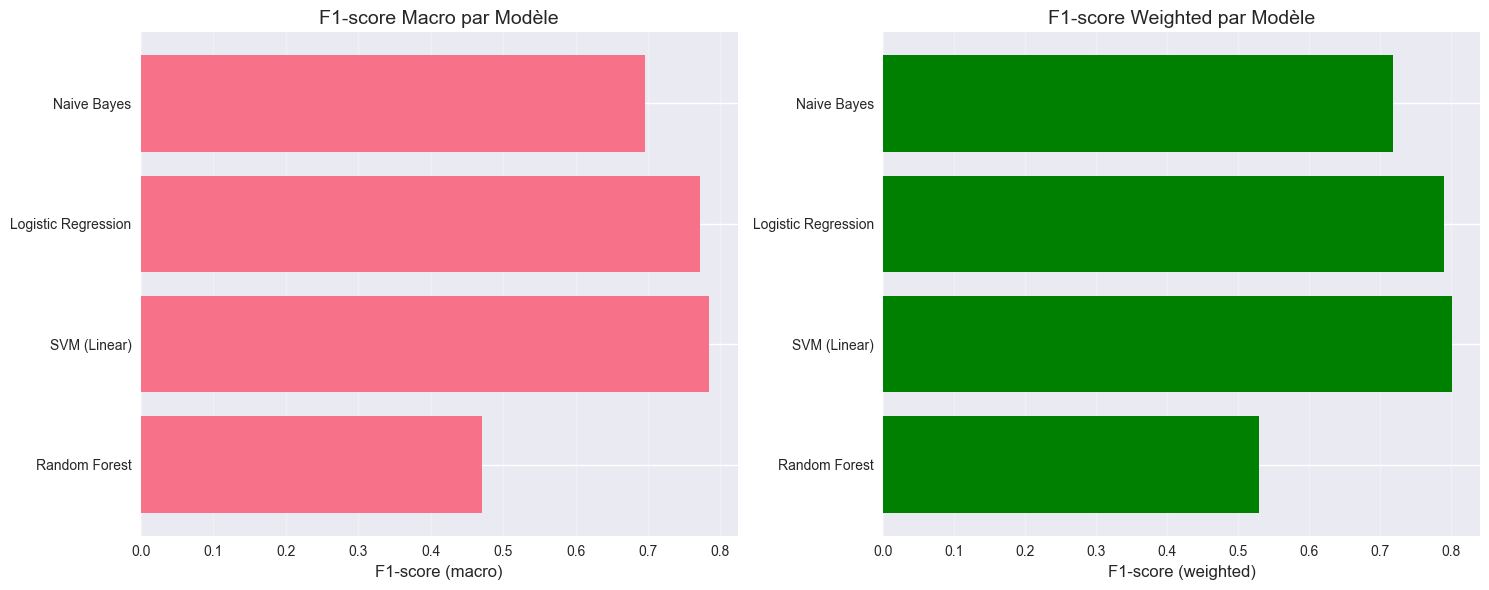

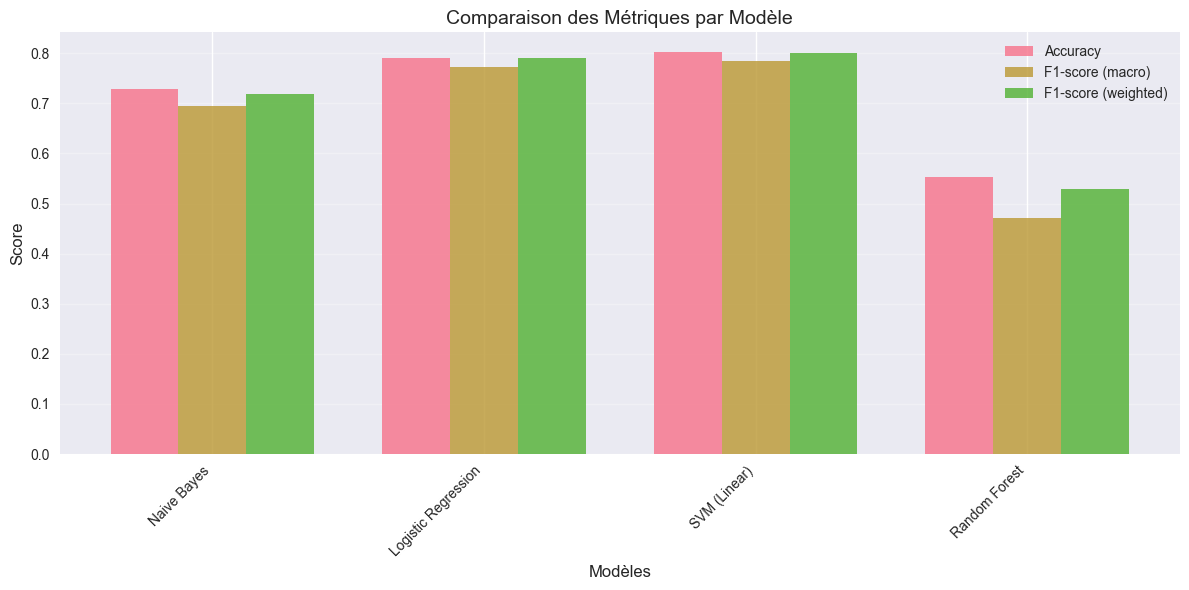

In [8]:
# Graphique de comparaison des modèles
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# F1-score macro
axes[0].barh(results_df['Model'], results_df['F1_macro'])
axes[0].set_xlabel('F1-score (macro)', fontsize=12)
axes[0].set_title('F1-score Macro par Modèle', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# F1-score weighted
axes[1].barh(results_df['Model'], results_df['F1_weighted'], color='green')
axes[1].set_xlabel('F1-score (weighted)', fontsize=12)
axes[1].set_title('F1-score Weighted par Modèle', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, results_df['F1_macro'], width, label='F1-score (macro)', alpha=0.8)
ax.bar(x + width, results_df['F1_weighted'], width, label='F1-score (weighted)', alpha=0.8)

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Métriques par Modèle', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.2 Analyse Détaillée du Meilleur Modèle

Analyse approfondie du modèle le plus performant.


In [9]:
# Identifier le meilleur modèle (basé sur F1-score macro)
best_model_name = results_df.loc[results_df['F1_macro'].idxmax(), 'Model']
print(f"🏆 Meilleur modèle : {best_model_name}")
print(f"   F1-score (macro) : {results_df.loc[results_df['F1_macro'].idxmax(), 'F1_macro']:.4f}")
print(f"   F1-score (weighted) : {results_df.loc[results_df['F1_macro'].idxmax(), 'F1_weighted']:.4f}")

# Prédictions du meilleur modèle
y_pred_best = baseline_models.predict(best_model_name, X_val_split)

# Rapport de classification détaillé
print(f"\n{'='*80}")
print(f"RAPPORT DE CLASSIFICATION DÉTAILLÉ - {best_model_name}")
print(f"{'='*80}")
print_classification_report(y_val_split, y_pred_best)



🏆 Meilleur modèle : SVM (Linear)
   F1-score (macro) : 0.7843
   F1-score (weighted) : 0.8008

RAPPORT DE CLASSIFICATION DÉTAILLÉ - SVM (Linear)
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

           0       0.43      0.52      0.47       623
           1       0.73      0.61      0.66       502
           2       0.78      0.79      0.78       336
           3       0.95      0.83      0.89       166
           4       0.72      0.77      0.74       534
           5       0.87      0.91      0.89       791
           6       0.66      0.46      0.55       153
           7       0.73      0.67      0.70       974
           8       0.64      0.49      0.55       414
           9       0.88      0.93      0.90      1009
          10       0.94      0.94      0.94       161
          11       0.82      0.76      0.79       498
          12       0.78      0.75      0.77       648
          13       0.84      0.83      0.83      1015
          14      

### 6.3 Matrice de Confusion

Visualisation de la matrice de confusion pour identifier les classes confondues.


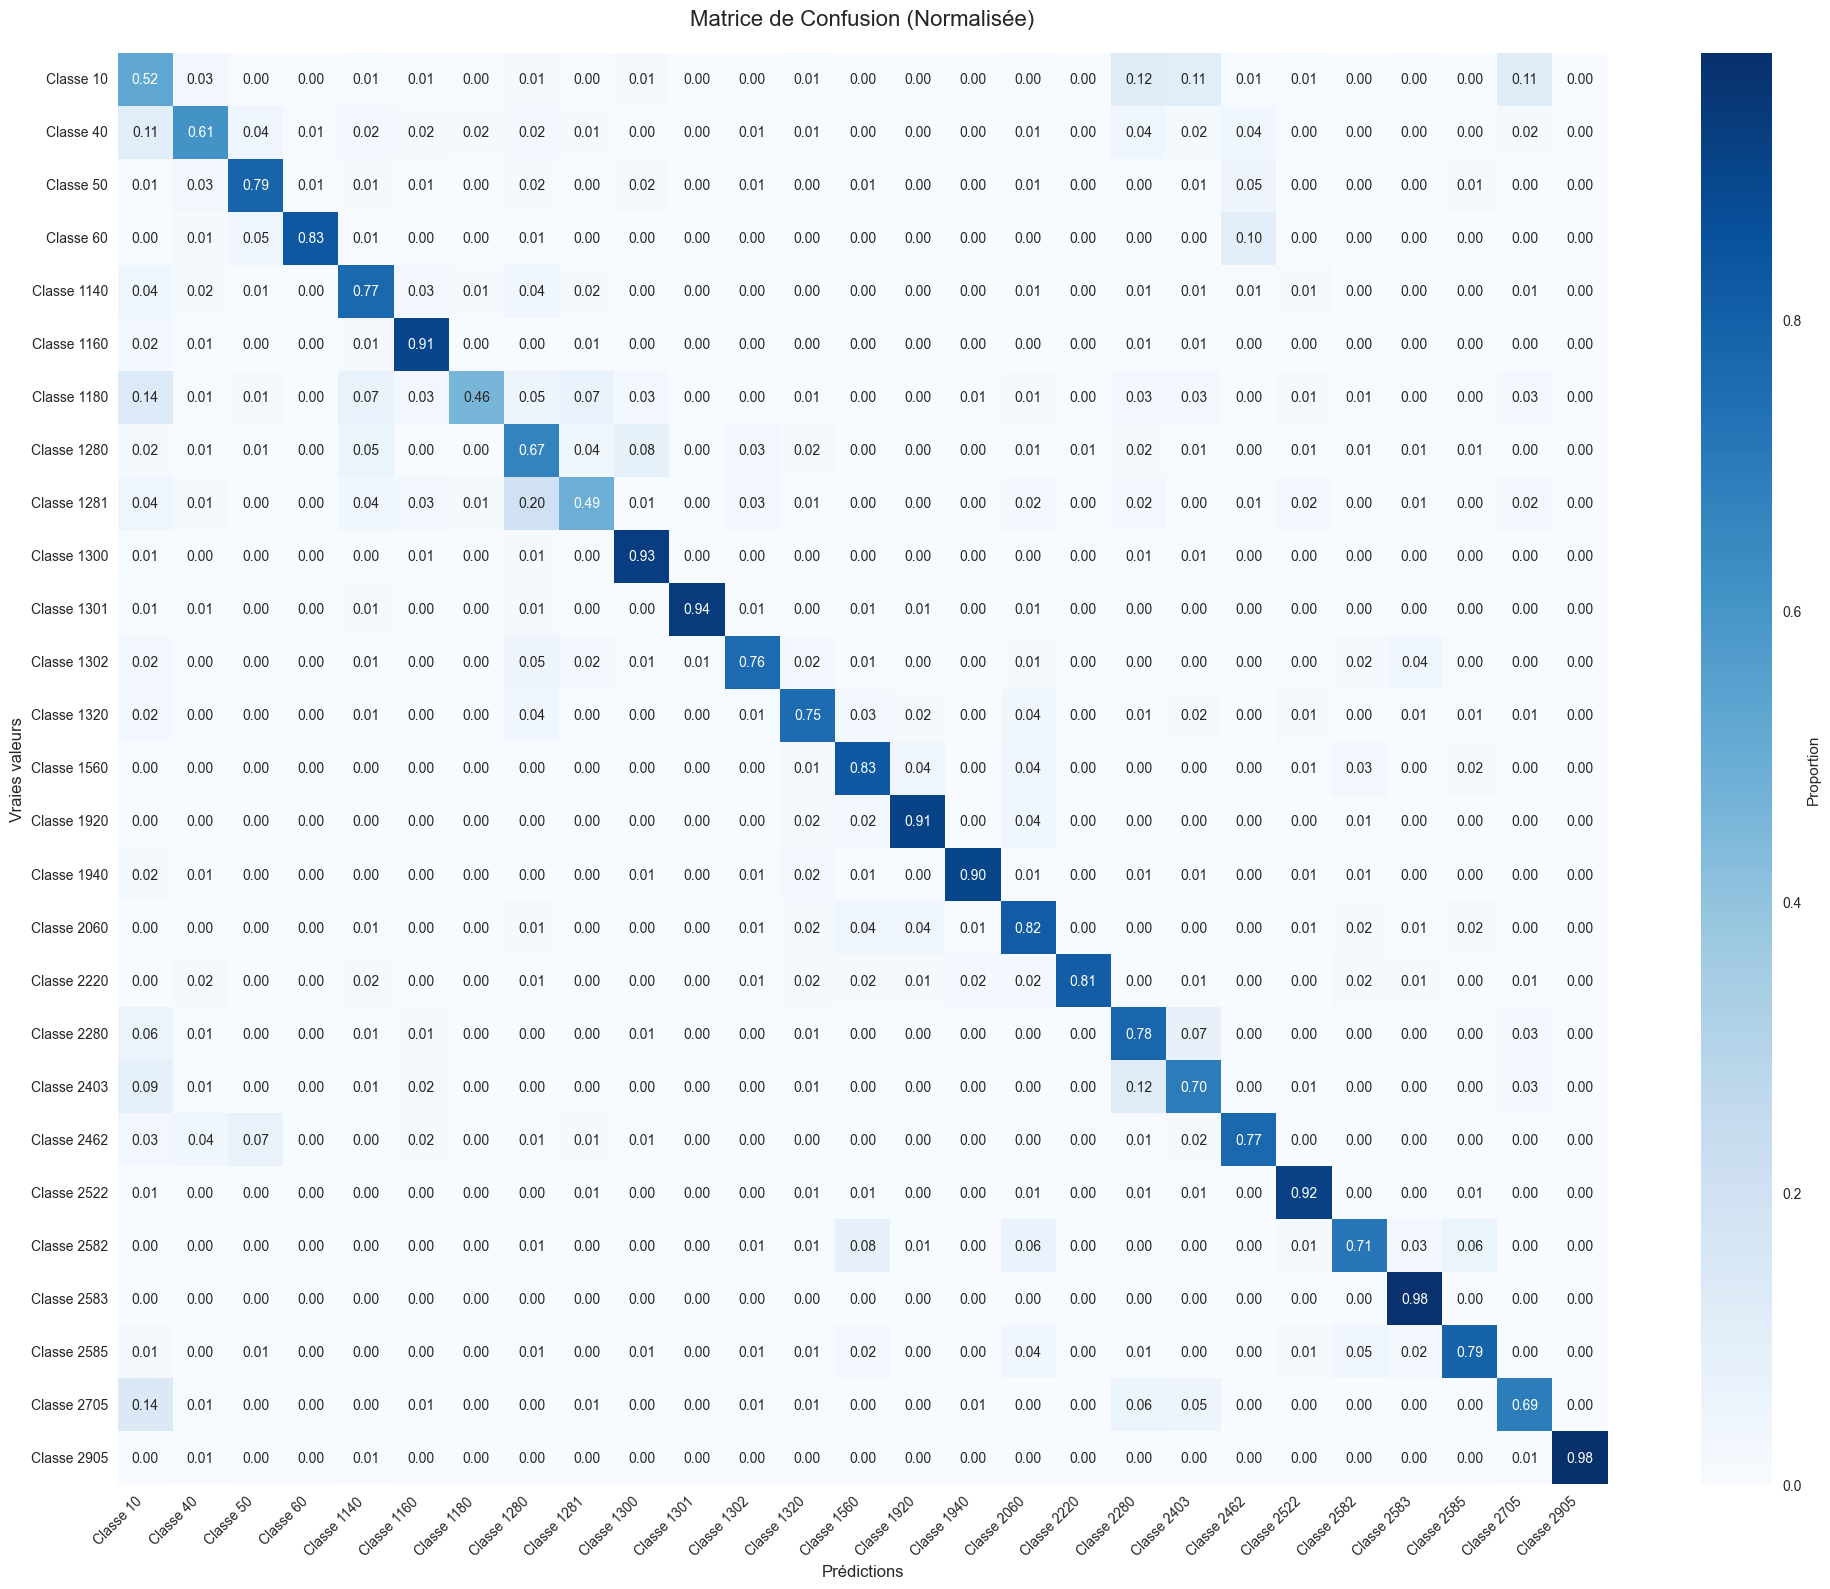

In [10]:
# Matrice de confusion pour le meilleur modèle
class_names = [f"Classe {cls}" for cls in sorted(label_encoder.classes_)]
plot_confusion_matrix(
    y_val_split,
    y_pred_best,
    class_names=class_names,
    figsize=(20, 16),
    normalize=True
)



### 6.4 Distribution des Classes : Réel vs Prédit

Comparaison de la distribution des classes réelles et prédites.


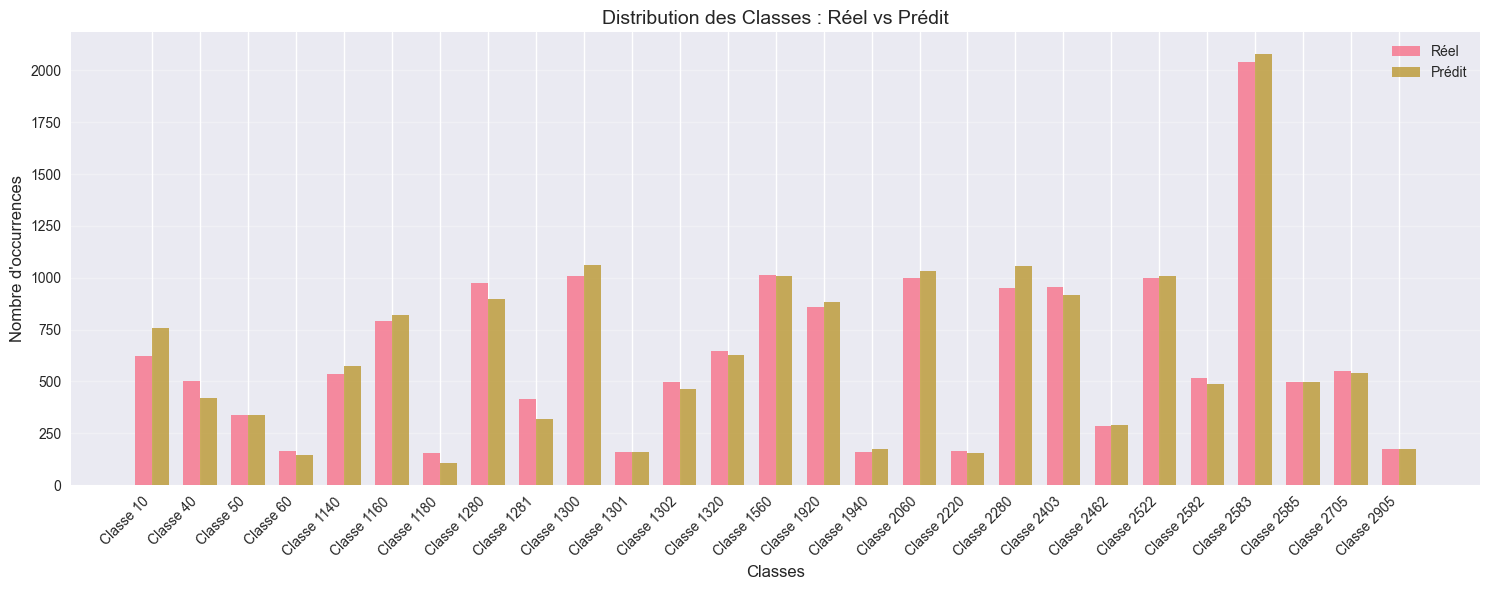

In [11]:
# Distribution des classes
plot_class_distribution(y_val_split, y_pred_best, class_names=class_names)



## 7. Validation Croisée

Validation croisée pour obtenir une estimation plus robuste des performances.


In [12]:
# Validation croisée sur les modèles (5 folds)
print("="*80)
print("VALIDATION CROISÉE (5 folds)")
print("="*80)

cv_results = {}

for model_name in models.keys():
    print(f"\n🔄 Validation croisée pour {model_name}...")
    cv_result = baseline_models.cross_validate(
        model_name,
        X_train_vect,
        y_train_encoded,
        cv=5,
        scoring='f1_macro'
    )
    cv_results[model_name] = cv_result
    print(f"  - F1-score (macro) moyen : {cv_result['mean']:.4f} (+/- {cv_result['std']*2:.4f})")

# Comparaison des résultats de validation croisée
print(f"\n{'='*80}")
print("RÉSULTATS DE VALIDATION CROISÉE")
print(f"{'='*80}")
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'CV_F1_mean': [cv_results[m]['mean'] for m in cv_results.keys()],
    'CV_F1_std': [cv_results[m]['std'] for m in cv_results.keys()]
}).sort_values('CV_F1_mean', ascending=False)

print(cv_summary.to_string(index=False))



VALIDATION CROISÉE (5 folds)

🔄 Validation croisée pour Naive Bayes...
  - F1-score (macro) moyen : 0.6904 (+/- 0.0105)

🔄 Validation croisée pour Logistic Regression...
  - F1-score (macro) moyen : 0.7674 (+/- 0.0092)

🔄 Validation croisée pour SVM (Linear)...
  - F1-score (macro) moyen : 0.7813 (+/- 0.0060)

🔄 Validation croisée pour Random Forest...
  - F1-score (macro) moyen : 0.4749 (+/- 0.0090)

RÉSULTATS DE VALIDATION CROISÉE
              Model  CV_F1_mean  CV_F1_std
       SVM (Linear)    0.781333   0.002992
Logistic Regression    0.767411   0.004607
        Naive Bayes    0.690421   0.005253
      Random Forest    0.474947   0.004492


## 8. Analyse des Erreurs

Analyse des erreurs de classification pour identifier les patterns et axes d'amélioration.


In [13]:
# Analyse des erreurs pour le meilleur modèle
errors_mask = y_val_split != y_pred_best
n_errors = errors_mask.sum()
n_total = len(y_val_split)

print(f"📊 Analyse des Erreurs - {best_model_name}")
print(f"{'='*80}")
print(f"  - Nombre total d'échantillons : {n_total:,}")
print(f"  - Nombre d'erreurs : {n_errors:,}")
print(f"  - Taux d'erreur : {n_errors/n_total*100:.2f}%")
print(f"  - Taux de réussite : {(1-n_errors/n_total)*100:.2f}%")

# Analyse par classe : quelles classes sont le plus souvent confondues ?
print(f"\n📊 Confusions les plus fréquentes :")
confusion_pairs = []
for true_label, pred_label in zip(y_val_split[errors_mask], y_pred_best[errors_mask]):
    true_class = label_encoder.inverse_transform([true_label])[0]
    pred_class = label_encoder.inverse_transform([pred_label])[0]
    confusion_pairs.append((true_class, pred_class))

confusion_df = pd.Series(confusion_pairs).value_counts().head(10)
print("\nTop 10 confusions :")
for (true_class, pred_class), count in confusion_df.items():
    print(f"  {true_class} → {pred_class} : {count} fois")



📊 Analyse des Erreurs - SVM (Linear)
  - Nombre total d'échantillons : 16,984
  - Nombre d'erreurs : 3,370
  - Taux d'erreur : 19.84%
  - Taux de réussite : 80.16%

📊 Confusions les plus fréquentes :

Top 10 confusions :
  2403 → 2280 : 114 fois
  2403 → 10 : 87 fois
  1281 → 1280 : 84 fois
  2705 → 10 : 77 fois
  1280 → 1300 : 76 fois
  10 → 2280 : 75 fois
  10 → 2705 : 71 fois
  2280 → 2403 : 71 fois
  10 → 2403 : 69 fois
  2280 → 10 : 57 fois


## 9. Sauvegarde des Modèles

Sauvegarde du meilleur modèle et du vectoriseur pour utilisation future.


In [14]:
# Sauvegarde du meilleur modèle
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print("💾 Sauvegarde des modèles...")

# Sauvegarder le meilleur modèle
baseline_models.save_model(best_model_name, MODELS_DIR / f'{best_model_name.lower().replace(" ", "_")}_baseline.pkl')
print(f"✅ Modèle {best_model_name} sauvegardé")

# Sauvegarder le vectoriseur
vectorizer.save(MODELS_DIR / 'tfidf_vectorizer.pkl')
print(f"✅ Vectoriseur TF-IDF sauvegardé")

print(f"\n📁 Fichiers sauvegardés dans : {MODELS_DIR}")



💾 Sauvegarde des modèles...
✅ Modèle SVM (Linear) sauvegardé
✅ Vectoriseur TF-IDF sauvegardé

📁 Fichiers sauvegardés dans : ..\models


## 10. Analyse et Recommandations

### 10.1 Pertinence de l'Approche

Analyse de la pertinence de l'approche baseline.


In [15]:
print("="*80)
print("ANALYSE DE LA PERTINENCE DE L'APPROCHE")
print("="*80)

# Résultats du meilleur modèle
best_f1_macro = results_df.loc[results_df['F1_macro'].idxmax(), 'F1_macro']
best_f1_weighted = results_df.loc[results_df['F1_macro'].idxmax(), 'F1_weighted']
best_accuracy = results_df.loc[results_df['F1_macro'].idxmax(), 'Accuracy']

print(f"\n📊 Performances du meilleur modèle ({best_model_name}) :")
print(f"  - Accuracy : {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"  - F1-score (macro) : {best_f1_macro:.4f}")
print(f"  - F1-score (weighted) : {best_f1_weighted:.4f}")

# Analyse de la pertinence
print(f"\n💡 Analyse :")
if best_f1_macro > 0.7:
    print(f"  ✅ Excellentes performances ! L'approche est très pertinente.")
elif best_f1_macro > 0.5:
    print(f"  ✅ Bonnes performances. L'approche est pertinente mais peut être améliorée.")
elif best_f1_macro > 0.3:
    print(f"  ⚠️  Performances modérées. L'approche est prometteuse mais nécessite des améliorations.")
else:
    print(f"  ❌ Performances faibles. L'approche nécessite des ajustements significatifs.")

# Comparaison avec baseline aléatoire
random_baseline = 1 / len(label_encoder.classes_)
print(f"\n📈 Comparaison avec baseline aléatoire :")
print(f"  - Baseline aléatoire (27 classes) : {random_baseline:.4f} ({random_baseline*100:.2f}%)")
print(f"  - Amélioration : {((best_f1_macro - random_baseline) / random_baseline * 100):.1f}%")



ANALYSE DE LA PERTINENCE DE L'APPROCHE

📊 Performances du meilleur modèle (SVM (Linear)) :
  - Accuracy : 0.8016 (80.16%)
  - F1-score (macro) : 0.7843
  - F1-score (weighted) : 0.8008

💡 Analyse :
  ✅ Excellentes performances ! L'approche est très pertinente.

📈 Comparaison avec baseline aléatoire :
  - Baseline aléatoire (27 classes) : 0.0370 (3.70%)
  - Amélioration : 2017.7%


### 10.2 Axes d'Amélioration Identifiés


In [16]:
print("="*80)
print("AXES D'AMÉLIORATION IDENTIFIÉS")
print("="*80)

print("\n🔍 Problèmes identifiés :")

# 1. Déséquilibre de classes
print("\n1. Déséquilibre de classes :")
print("   - Certaines classes sont sous-représentées")
print("   - Le modèle peut être biaisé vers les classes majoritaires")
print("   - Solution : Utiliser class weights ou techniques de rééquilibrage (SMOTE)")

# 2. Confusions entre classes
print("\n2. Confusions entre classes :")
print("   - Analyse des confusions les plus fréquentes nécessaire")
print("   - Certaines classes peuvent être sémantiquement proches")
print("   - Solution : Feature engineering supplémentaire, embeddings sémantiques")

# 3. Vectorisation TF-IDF
print("\n3. Vectorisation TF-IDF :")
print("   - TF-IDF capture les fréquences mais pas la sémantique")
print("   - Limité à 10 000 features peut perdre de l'information")
print("   - Solution : Essayer Word2Vec, FastText, ou BERT pour capturer la sémantique")

# 4. Modèles baselines
print("\n4. Modèles baselines :")
print("   - Les modèles baselines sont simples mais efficaces")
print("   - Peuvent être améliorés avec des modèles plus complexes")
print("   - Solution : Essayer XGBoost, CatBoost, ou modèles deep learning")

print("\n✅ Recommandations pour les prochaines étapes :")
print("   1. Optimiser les hyperparamètres des modèles baselines")
print("   2. Tester des techniques de rééquilibrage (class weights, SMOTE)")
print("   3. Essayer des embeddings sémantiques (Word2Vec, BERT)")
print("   4. Tester des modèles plus complexes (XGBoost, Neural Networks)")
print("   5. Feature engineering supplémentaire (combinaison de features textuelles et numériques)")



AXES D'AMÉLIORATION IDENTIFIÉS

🔍 Problèmes identifiés :

1. Déséquilibre de classes :
   - Certaines classes sont sous-représentées
   - Le modèle peut être biaisé vers les classes majoritaires
   - Solution : Utiliser class weights ou techniques de rééquilibrage (SMOTE)

2. Confusions entre classes :
   - Analyse des confusions les plus fréquentes nécessaire
   - Certaines classes peuvent être sémantiquement proches
   - Solution : Feature engineering supplémentaire, embeddings sémantiques

3. Vectorisation TF-IDF :
   - TF-IDF capture les fréquences mais pas la sémantique
   - Limité à 10 000 features peut perdre de l'information
   - Solution : Essayer Word2Vec, FastText, ou BERT pour capturer la sémantique

4. Modèles baselines :
   - Les modèles baselines sont simples mais efficaces
   - Peuvent être améliorés avec des modèles plus complexes
   - Solution : Essayer XGBoost, CatBoost, ou modèles deep learning

✅ Recommandations pour les prochaines étapes :
   1. Optimiser les hype

## 11. Synthèse et Prochaines Étapes

### Résumé des Résultats

- ✅ Modèles baselines entraînés et évalués
- ✅ Meilleur modèle identifié : **[sera rempli après exécution]**
- ✅ Performances initiales : **[sera rempli après exécution]**
- ✅ Axes d'amélioration identifiés

### Prochaines Étapes → Notebook 05

1. **Optimisation des hyperparamètres** : GridSearch, RandomSearch sur le SVM
2. **Techniques de rééquilibrage** : Class weights, SMOTE, ADASYN
3. **Modèles plus complexes** : XGBoost, CatBoost, Neural Networks
4. **Embeddings sémantiques** : Word2Vec, FastText, BERT
5. **Feature engineering avancé** : Combinaison features textuelles + numériques

### Fichiers Générés

- `models/tfidf_vectorizer.pkl` : Vectoriseur TF-IDF entraîné
- `models/[model]_baseline.pkl` : Meilleur modèle baseline
- `models/label_encoder.pkl` : Encoder des labels

